<a href="https://colab.research.google.com/github/taniadamya/telco-churn-analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-cloud-bigquery pandas matplotlib seaborn scikit-learn db-dtypes

In [2]:
from google.cloud import bigquery
from google.colab import auth

auth.authenticate_user()

client = bigquery.Client(project='telco-churn-analysis-498613')

query = """
SELECT *
FROM `telco-churn-analysis-498613.telco_chrun.master_churn`
"""

df = client.query(query).to_dataframe()
print(f"Data shape: {df.shape}")
print(df.head())

Data shape: (7043, 24)
   CustomerID         City  Zip_Code  Churn_Label  Churn_Value  Churn_Score  \
0  3307-TLCUD  Los Angeles     90001        False            0           45   
1  0136-IFMYD  Los Angeles     90001        False            0           63   
2  7590-VHVEG  Los Angeles     90001        False            0           27   
3  5144-TVGLP  Los Angeles     90002        False            0           71   
4  5575-GNVDE  Los Angeles     90002        False            0           61   

   Monthly_Charges Total_Charges        Contract Internet_Service  ...  \
0            34.40        592.75  Month-to-month              DSL  ...   
1           109.95       7634.25        Two year      Fiber optic  ...   
2            29.85         29.85  Month-to-month              DSL  ...   
3            94.75          3653  Month-to-month      Fiber optic  ...   
4            56.95        1889.5        One year              DSL  ...   

   Gender  Age Senior_Citizen  Married Dependents  Number

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(" SHAPE ")
print(df.shape)

print("\n DATA TYPES ")
print(df.dtypes)

print("\n MISSING VALUES ")
print(df.isnull().sum())

print("\n DUPLICATES ")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n BASIC STATS ")
print(df.describe())

 SHAPE 
(7043, 24)

 DATA TYPES 
CustomerID               object
City                     object
Zip_Code                  Int64
Churn_Label             boolean
Churn_Value               Int64
Churn_Score               Int64
Monthly_Charges         float64
Total_Charges            object
Contract                 object
Internet_Service         object
Phone_Service           boolean
Tenure_Months             Int64
Payment_Method           object
Paperless_Billing       boolean
Gender                   object
Age                       Int64
Senior_Citizen          boolean
Married                 boolean
Dependents              boolean
Number_of_Dependents      Int64
State                    object
Latitude                float64
Longitude               float64
Population                Int64
dtype: object

 MISSING VALUES 
CustomerID              0
City                    0
Zip_Code                0
Churn_Label             0
Churn_Value             0
Churn_Score             0
Monthly_Cha

In [4]:
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

print(f"Missing Total_Charges after convert: {df['Total_Charges'].isnull().sum()}")

df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)

df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 29, 45, 60, 100],
                          labels=['Under 30', '30-45', '46-60', 'Above 60'])

df['Tenure_Group'] = pd.cut(df['Tenure_Months'],
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12 mo', '13-24 mo', '25-36 mo',
                                     '37-48 mo', '49-60 mo', '61-72 mo'])

print("Cleaning selesai!")
print(f"\nAge Group distribution:\n{df['Age_Group'].value_counts()}")
print(f"\nTenure Group distribution:\n{df['Tenure_Group'].value_counts()}")

Missing Total_Charges after convert: 11
Cleaning selesai!

Age Group distribution:
Age_Group
30-45       2071
46-60       1909
Above 60    1662
Under 30    1401
Name: count, dtype: int64

Tenure Group distribution:
Tenure_Group
0-12 mo     2175
61-72 mo    1407
13-24 mo    1024
25-36 mo     832
49-60 mo     832
37-48 mo     762
Name: count, dtype: int64


/tmp/ipykernel_1063/3595653448.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)


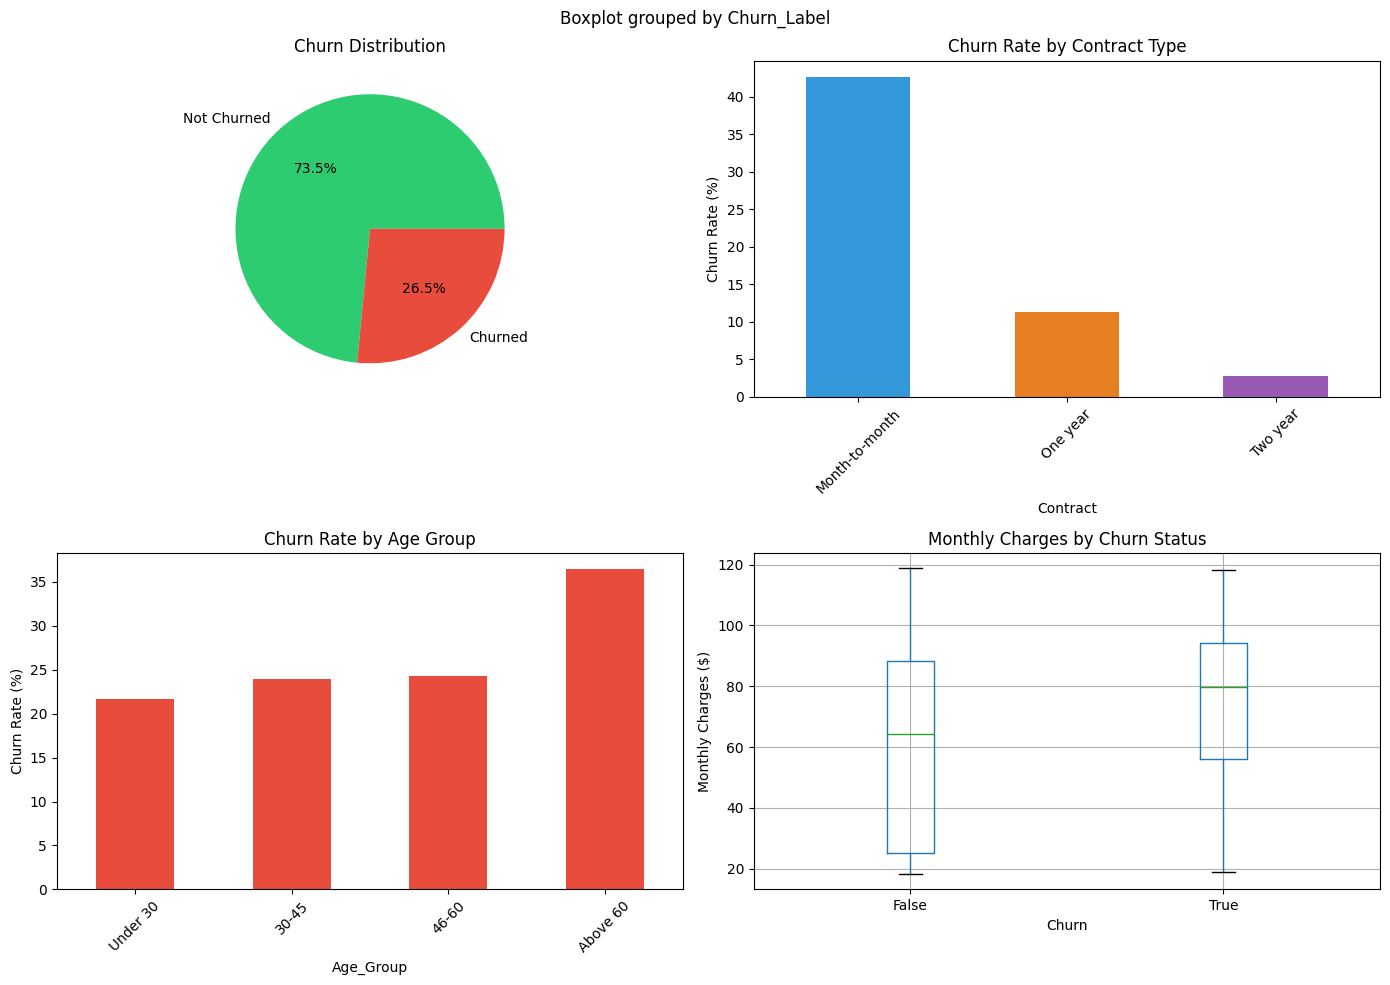

EDA plot saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Analysis - EDA', fontsize=16, fontweight='bold')


churn_counts = df['Churn_Label'].value_counts()
axes[0,0].pie(churn_counts, labels=['Not Churned', 'Churned'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Churn Distribution')

contract_churn = df.groupby('Contract')['Churn_Value'].mean() * 100
contract_churn.plot(kind='bar', ax=axes[0,1], color=['#3498db','#e67e22','#9b59b6'])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)


age_churn = df.groupby('Age_Group', observed=True)['Churn_Value'].mean() * 100
age_churn.plot(kind='bar', ax=axes[1,0], color='#e74c3c')
axes[1,0].set_title('Churn Rate by Age Group')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)


df.boxplot(column='Monthly_Charges', by='Churn_Label', ax=axes[1,1])
axes[1,1].set_title('Monthly Charges by Churn Status')
axes[1,1].set_xlabel('Churn')
axes[1,1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved!")

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

features = ['Monthly_Charges', 'Total_Charges', 'Tenure_Months',
            'Age', 'Number_of_Dependents', 'Population',
            'Contract', 'Internet_Service', 'Payment_Method',
            'Gender', 'Senior_Citizen', 'Married',
            'Paperless_Billing', 'Phone_Service']

df_ml = df[features + ['Churn_Value']].copy()

le = LabelEncoder()
cat_cols = ['Contract', 'Internet_Service', 'Payment_Method',
            'Gender', 'Phone_Service']

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


bool_cols = ['Senior_Citizen', 'Married', 'Paperless_Billing']
for col in bool_cols:
    df_ml[col] = df_ml[col].astype(int)


X = df_ml.drop('Churn_Value', axis=1)
y = df_ml['Churn_Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test: {y_test.mean()*100:.2f}%")

Train size: (5634, 14)
Test size: (1409, 14)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]


print("MODEL PERFORMANCE")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\n CLASSIFICATION REPORT ")
print(classification_report(y_test, y_pred))


feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n TOP 10 FEATURE IMPORTANCE ")
print(feat_importance.head(10))

MODEL PERFORMANCE
ROC-AUC Score: 0.8743

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         0.0       0.90      0.82      0.86      1035
         1.0       0.60      0.76      0.67       374

    accuracy                           0.80      1409
   macro avg       0.75      0.79      0.77      1409
weighted avg       0.82      0.80      0.81      1409


 TOP 10 FEATURE IMPORTANCE 
                 Feature  Importance
6               Contract    0.199788
2          Tenure_Months    0.161440
0        Monthly_Charges    0.133163
1          Total_Charges    0.117853
4   Number_of_Dependents    0.082820
7       Internet_Service    0.077722
5             Population    0.066709
3                    Age    0.058623
8         Payment_Method    0.039027
12     Paperless_Billing    0.022928


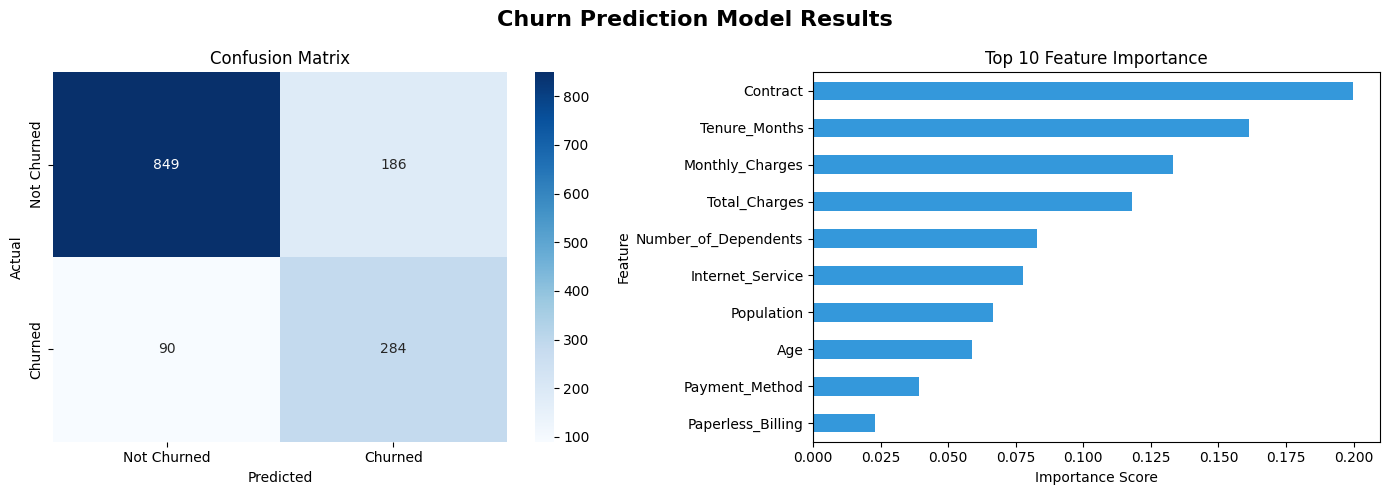

Model visualization saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Prediction Model Results', fontsize=16, fontweight='bold')


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

feat_importance.head(10).plot(
    kind='barh', x='Feature', y='Importance',
    ax=axes[1], color='#3498db', legend=False)
axes[1].set_title('Top 10 Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model visualization saved!")

In [10]:
print("=" * 55)
print("   CUSTOMER CHURN ANALYSIS - BUSINESS INSIGHTS")
print("=" * 55)

print("""
📊 KEY FINDINGS:
─────────────────────────────────────────────────────
1. CHURN RATE OVERALL: 26.54% (1,869 dari 7,043 customers)

2. CONTRACT TYPE (Faktor terbesar):
   • Month-to-month : 42.71% churn rate ⚠️
   • One year       : 11.27% churn rate
   • Two year       :  2.83% churn rate ✅

3. INTERNET SERVICE:
   • Fiber optic    : 69.4% dari total churners
   • DSL            : 24.6% dari total churners

4. TENURE:
   • 0-12 bulan pertama adalah periode PALING KRITIS
   • Churn drastis turun setelah bulan ke-12

5. AGE GROUP:
   • Above 60 tahun : churn rate tertinggi ~36%
   • Under 30 tahun : churn rate terendah ~22%

6. MONTHLY CHARGES:
   • Customer yang churn rata-rata bayar lebih tinggi
   • Median churner: $80/bulan vs non-churner: $65/bulan

🤖 MODEL PERFORMANCE:
─────────────────────────────────────────────────────
   • Algorithm  : Random Forest Classifier
   • ROC-AUC    : 0.8743 (Sangat Baik)
   • Accuracy   : 80%
   • F1-Score   : 0.67 (untuk kelas Churn)

💡 REKOMENDASI BISNIS:
─────────────────────────────────────────────────────
1. Tawarkan DISKON untuk upgrade ke kontrak tahunan
   → Potensi kurangi churn dari 42% ke <11%

2. Program ONBOARDING KHUSUS untuk 12 bulan pertama
   → Periode paling kritis untuk retensi customer

3. Review HARGA Fiber optic
   → 69% churner pakai Fiber optic dengan charges tinggi

4. Program LOYALITAS untuk customer 60+ tahun
   → Segmen dengan churn rate tertinggi
""")

   CUSTOMER CHURN ANALYSIS - BUSINESS INSIGHTS

📊 KEY FINDINGS:
─────────────────────────────────────────────────────
1. CHURN RATE OVERALL: 26.54% (1,869 dari 7,043 customers)

2. CONTRACT TYPE (Faktor terbesar):
   • Month-to-month : 42.71% churn rate ⚠️
   • One year       : 11.27% churn rate
   • Two year       :  2.83% churn rate ✅

3. INTERNET SERVICE:
   • Fiber optic    : 69.4% dari total churners
   • DSL            : 24.6% dari total churners

4. TENURE:
   • 0-12 bulan pertama adalah periode PALING KRITIS
   • Churn drastis turun setelah bulan ke-12

5. AGE GROUP:
   • Above 60 tahun : churn rate tertinggi ~36%
   • Under 30 tahun : churn rate terendah ~22%

6. MONTHLY CHARGES:
   • Customer yang churn rata-rata bayar lebih tinggi
   • Median churner: $80/bulan vs non-churner: $65/bulan

🤖 MODEL PERFORMANCE:
─────────────────────────────────────────────────────
   • Algorithm  : Random Forest Classifier
   • ROC-AUC    : 0.8743 (Sangat Baik)
   • Accuracy   : 80%
   • F1-Sco